# Homework 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## Preparing the data

In [3]:
df = pd.read_csv("car_fuel_efficiency_2026.csv")
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [6]:
df = df[['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


## EDA

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

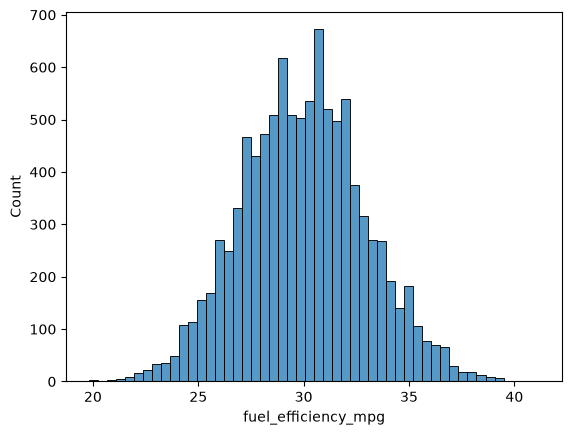

In [8]:
sns.histplot(df["fuel_efficiency_mpg"], bins=50)

It does not have a long tail.

In [9]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

## Question 1
horsepower has missing values

In [11]:
df["horsepower"].median()

np.float64(254.0)

## Question 2
Median of horsepower is 254.

### Prepare and split the dataset

In [12]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [14]:
df_train.index

Index([6252, 4684, 1731, 4742, 4521, 6340,  576, 5202, 6363,  439,
       ...
       3832, 8917, 4776, 4276,  253, 7895, 9590, 7288,  278, 3252],
      dtype='int64', length=6000)

In [16]:
len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

In [36]:
df_train = df_train.reset_index(drop = True)
df_val = df_val.reset_index(drop = True)
df_test = df_test.reset_index(drop = True)
y_train = df_train["fuel_efficiency_mpg"].values
y_val = df_val["fuel_efficiency_mpg"].values
y_test = df_test["fuel_efficiency_mpg"].values

del df_train["fuel_efficiency_mpg"]
del df_val["fuel_efficiency_mpg"]
del df_test["fuel_efficiency_mpg"]

In [37]:
def prepare_X_zero(X, missing = ["horsepower"]):
    X = X.copy()
    X[missing] = X[missing].fillna(0)
    return X.values

mean_X_train = df_train["horsepower"].mean()

def prepare_X_mean(X, missing = ["horsepower"], mean = mean_X_train):
    X = X.copy()
    X[missing] = X[missing].fillna(mean)
    return X.values

    

In [38]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [46]:
X_train_zero = prepare_X_zero(df_train)
X_val_zero = prepare_X_zero(df_val)
X_test_zero = prepare_X_zero(df_test)
X_train_mean = prepare_X_mean(df_train, mean = mean_X_train)
X_val_mean = prepare_X_mean(df_val, mean = mean_X_train)
X_test_mean = prepare_X_mean(df_test, mean = mean_X_train)

In [47]:
w0_zero, w_zero = train_linear_regression(X_train_zero, y_train)
w0_mean, w_mean = train_linear_regression(X_train_mean, y_train)

In [48]:
y_pred_zero = w0_zero + X_val_zero @ w_zero 
y_pred_mean =  w0_mean + X_val_mean @ w_mean

In [49]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [50]:
print(round(rmse(y_val,y_pred_zero),3))
print(round(rmse(y_val,y_pred_mean),3))

2.205
2.202


<Axes: ylabel='Count'>

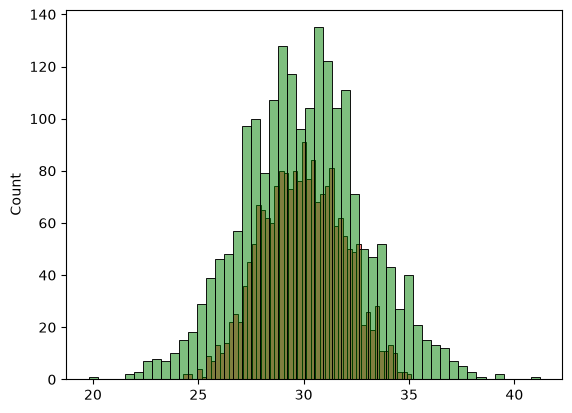

In [60]:
sns.histplot(y_pred_mean, bins = 50, color = "red", alpha = 0.5)
sns.histplot(y_val, bins = 50, color = "green", alpha = 0.5)

## Question 3
The option with mean is better.

In [61]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [62]:
r = [0, 0.01, 0.1, 1, 5, 10, 100]

In [67]:
for i in r:
    W_0, W = train_linear_regression_reg(X_train_zero, y_train, r = i)
    y_pred = W_0 + X_val_zero @ W
    print(f"{i}: {round(rmse(y_pred,y_val),4)}")

0: 2.2053
0.01: 2.2058
0.1: 2.2241
1: 2.3492
5: 2.4094
10: 2.4195
100: 2.4292


## Question 4
r = 0 gives the best result

In [68]:
seed = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [72]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test
rmse_list = []

for i in seed:
    np.random.seed(i)
    idx = np.arange(n)
    np.random.shuffle(idx)
    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    df_train = df_train.reset_index(drop = True)
    df_val = df_val.reset_index(drop = True)
    df_test = df_test.reset_index(drop = True)
    y_train = df_train["fuel_efficiency_mpg"].values
    y_val = df_val["fuel_efficiency_mpg"].values
    y_test = df_test["fuel_efficiency_mpg"].values
    del df_train["fuel_efficiency_mpg"]
    del df_val["fuel_efficiency_mpg"]
    del df_test["fuel_efficiency_mpg"]
    X_train_zero = prepare_X_zero(df_train)
    X_val_zero = prepare_X_zero(df_val)
    X_test_zero = prepare_X_zero(df_test)
    w0_zero, w_zero = train_linear_regression(X_train_zero, y_train)
    y_pred_zero = w0_zero + X_val_zero @ w_zero 
    rmse_list.append(rmse(y_val,y_pred_zero))

round(np.std(rmse_list),3)




np.float64(0.029)

## Question 5
The value of std is 0.029

In [75]:
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_val + n_train]]
df_test = df.iloc[idx[n_val+n_train:]]
df_test = df_test.reset_index(drop = True)
df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop = True)
y_full_train = df_full_train["fuel_efficiency_mpg"].values
y_test = df_test["fuel_efficiency_mpg"].values
del df_test["fuel_efficiency_mpg"]
del df_full_train["fuel_efficiency_mpg"]
X_full_train_zero = prepare_X_zero(df_full_train)
X_test_zero = prepare_X_zero(df_test)
W_0, W = train_linear_regression_reg(X_full_train_zero, y_full_train, r=0.001)
y_pred_test = W_0 + X_test_zero @ W
rmse(y_test, y_pred_test)



np.float64(2.235827747191731)

## Question 6
The RMSE is 2.236